📂 Loading PDB files from: /Users/jules/Desktop/HDACs-XLMS_2024-11-16/hdac1_mbd3_mta1_gatad2b_rbbp4_Non_Matched/structures/it1
📏 Calculating pairwise RMSD matrix...
🧠 Clustering structures...
📊 Plotting heatmap...


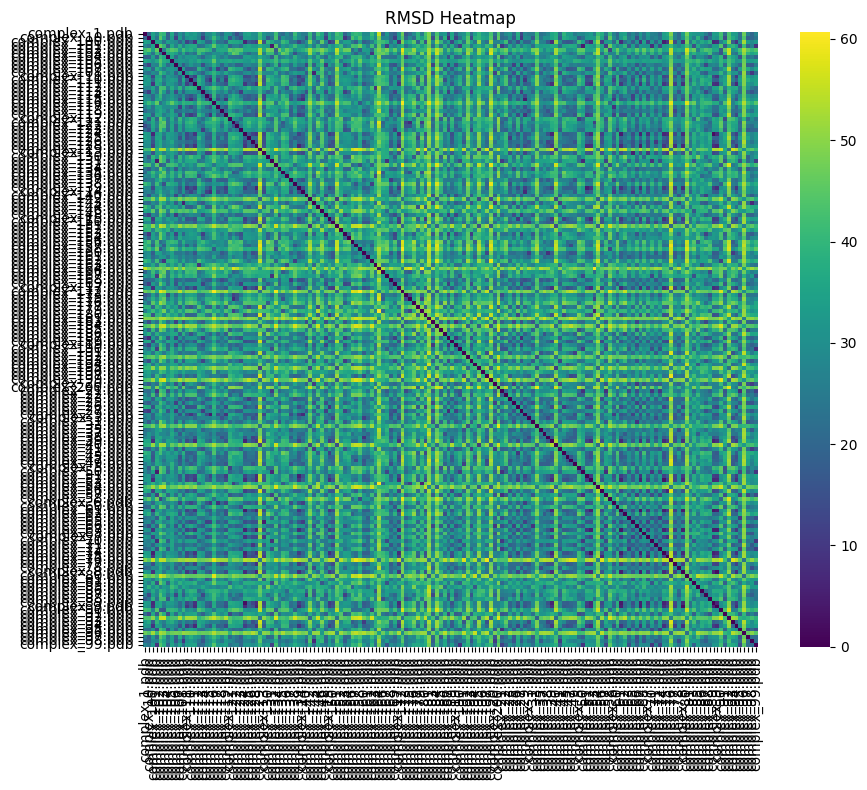

📈 Plotting RMSD distribution...


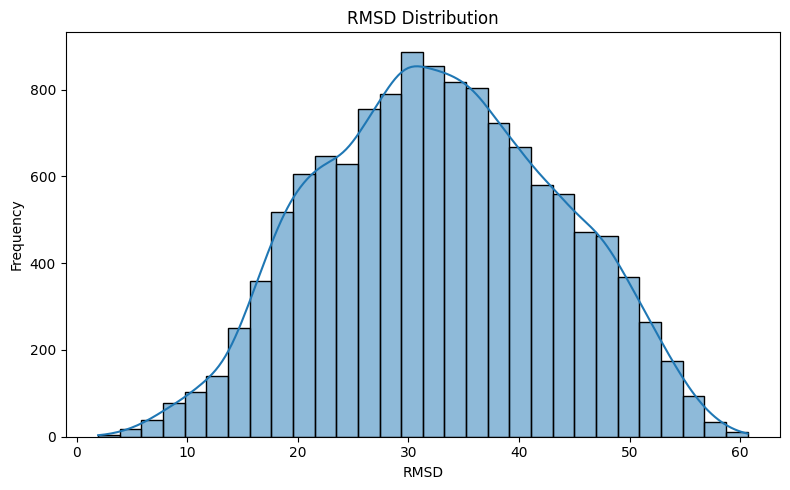

💾 Saving cluster assignments to CSV...
📦 Exporting clustered structures to folders...
Clustered structures exported to: /Users/jules/Desktop/HDACs-XLMS_2024-11-16/hdac1_mbd3_mta1_gatad2b_rbbp4_Non_Matched/structures/it1/clustered_structures/
✅ Clustering completed. Cluster summary:


,Structure
Cluster,
0,11
1,9
2,3
3,2
4,24
5,4
6,6
7,1
8,2


,Structure,Cluster
0,complex_1.pdb,0
1,complex_10.pdb,4
2,complex_100.pdb,28
3,complex_101.pdb,25
4,complex_102.pdb,22
...,...,...
155,complex_95.pdb,25
156,complex_96.pdb,19
157,complex_97.pdb,6
158,complex_98.pdb,4


In [ ]:
"""
 Proposed by Jules Nde, PhD, Washburn Lab, Cancer Biology, University of Kansas Medical Center (25/8/2025)

Author: Jules Nde, Washburn Lab, Cancer Biology, University of Kansas Medical Center
Copyright © 2025 by Jules Nde. All rights reserved. No part of this work may be reproduced or transmitted in any form without permission.
 
This script clusters pdb structures based on the root mean square deviation (RMSD). It uses as a input a path to the
directory that contains a list of PDBs of interest. It outputs a heatmap of different cluster, a barplot distribution, and a summary table.
Author: Jules Nde, Washburn Lab, Cancer Biology, University of Kansas Medical Center (Last modified: 10/27/2025)
 """

# USER DEFINED PARAMETERS
pdb_dir = 'structures/it1'   # Set your PDB directory
n_clusters = 30                       # Set number of clusters
output_dir = 'structures/it1/clustered_structures' # Output directory for clustered files

# ========================= LET'S GET STARTED ================================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from Bio.PDB import PDBParser, Superimposer
from sklearn.cluster import AgglomerativeClustering
from IPython.display import display

def load_structures(pdb_dir):
    parser = PDBParser(QUIET=True)
    pdb_files = sorted([f for f in os.listdir(pdb_dir) if f.endswith('.pdb')])
    structures, names = [], []
    for fname in pdb_files:
        structure = parser.get_structure(fname, os.path.join(pdb_dir, fname))
        structures.append(structure)
        names.append(fname)
    return structures, names, pdb_files

def get_ca_atoms(structure):
    ca_atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    ca_atoms.append(residue['CA'])
        break
    return ca_atoms

def calculate_rmsd_matrix(structures):
    n = len(structures)
    rmsd_matrix = np.zeros((n, n))
    for i in range(n):
        atoms_i = get_ca_atoms(structures[i])
        for j in range(i+1, n):
            atoms_j = get_ca_atoms(structures[j])
            min_len = min(len(atoms_i), len(atoms_j))
            if min_len == 0:
                rmsd = np.nan
            else:
                si = Superimposer()
                si.set_atoms(atoms_i[:min_len], atoms_j[:min_len])
                rmsd = si.rms
            rmsd_matrix[i, j] = rmsd
            rmsd_matrix[j, i] = rmsd
    return rmsd_matrix

def cluster_structures(rmsd_matrix, n_clusters):
    clustering = AgglomerativeClustering(
        metric='precomputed', linkage='average', n_clusters=n_clusters
    )
    labels = clustering.fit_predict(rmsd_matrix)
    return labels

def plot_rmsd_heatmap(rmsd_matrix, names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(rmsd_matrix, xticklabels=names, yticklabels=names, cmap='viridis', square=True)
    plt.title('RMSD Heatmap')
    plt.tight_layout()
    plt.show()

def plot_rmsd_distribution(rmsd_matrix):
    triu_indices = np.triu_indices_from(rmsd_matrix, k=1)
    rmsd_values = rmsd_matrix[triu_indices]
    rmsd_values = rmsd_values[~np.isnan(rmsd_values)]
    plt.figure(figsize=(8, 5))
    sns.histplot(rmsd_values, bins=30, kde=True)
    plt.xlabel('RMSD')
    plt.ylabel('Frequency')
    plt.title('RMSD Distribution')
    plt.tight_layout()
    plt.show()

def save_cluster_csv(names, labels, output='rmsd_clusters.csv'):
    df = pd.DataFrame({'Structure': names, 'Cluster': labels})
    df.to_csv(output, index=False)
    return df

def export_clustered_structures(pdb_dir, pdb_files, labels, output_base):
    if os.path.exists(output_base):
        shutil.rmtree(output_base)
    os.makedirs(output_base)

    for fname, label in zip(pdb_files, labels):
        cluster_folder = os.path.join(output_base, f'cluster_{label}')
        os.makedirs(cluster_folder, exist_ok=True)
        shutil.copy(os.path.join(pdb_dir, fname), os.path.join(cluster_folder, fname))

    print(f"Clustered structures exported to: {output_base}/")

# MAIN EXECUTION
print(f"📂 Loading PDB files from: {pdb_dir}")
structures, names, pdb_files = load_structures(pdb_dir)

print("📏 Calculating pairwise RMSD matrix...")
rmsd_matrix = calculate_rmsd_matrix(structures)

print("🧠 Clustering structures...")
labels = cluster_structures(rmsd_matrix, n_clusters)

print("📊 Plotting heatmap...")
plot_rmsd_heatmap(rmsd_matrix, names)

print("📈 Plotting RMSD distribution...")
plot_rmsd_distribution(rmsd_matrix)

print("💾 Saving cluster assignments to CSV...")
df_clusters = save_cluster_csv(names, labels)

print("📦 Exporting clustered structures to folders...")
export_clustered_structures(pdb_dir, pdb_files, labels, output_dir)

print("✅ Clustering completed. Cluster summary:")
display(df_clusters.groupby('Cluster').count())
display(df_clusters)
# =========================== IT WAS FUN CODING, SEE YOU NEXT TIME! KUMC, OCTOBER, 2025 ================================
